In [1]:
!pip uninstall -y scikit-learn scikeras
!pip install -q "scikit-learn==1.5.2" "scikeras==0.13.0"

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 101.5 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [4]:
import os

os.makedirs("plots_lab_2", exist_ok=True)

In [5]:
plt.rcParams["font.family"]="serif"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

In [6]:
(train_x,train_y),(test_x,test_y)=fashion_mnist.load_data()
train_x.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

In [7]:
train_y.shape

(60000,)

In [8]:
test_x.shape

(10000, 28, 28)

In [9]:
test_y.shape

(10000,)

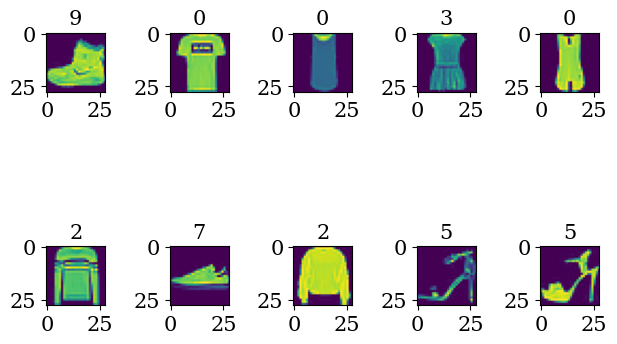

In [10]:
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(train_x[i])
  plt.title(train_y[i])

plt.tight_layout()
plt.savefig("plots_lab_2/fashion_mnist.png")
plt.show()

In [11]:
train_x=pd.DataFrame(train_x.reshape(60000,784))
train_y=pd.DataFrame(train_y)
train_x.head(10)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,22,...,0,0,0,0,133,167,73,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,1,1,0,0,0,...,0,0,3,0,82,237,231,70,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
train_y.head(10)

,0
0,9
1,0
2,0
3,3
4,0
5,2
6,7
7,2
8,5
9,5


In [13]:
test_x=pd.DataFrame(test_x.reshape(10000,784))
test_y=pd.DataFrame(test_y)

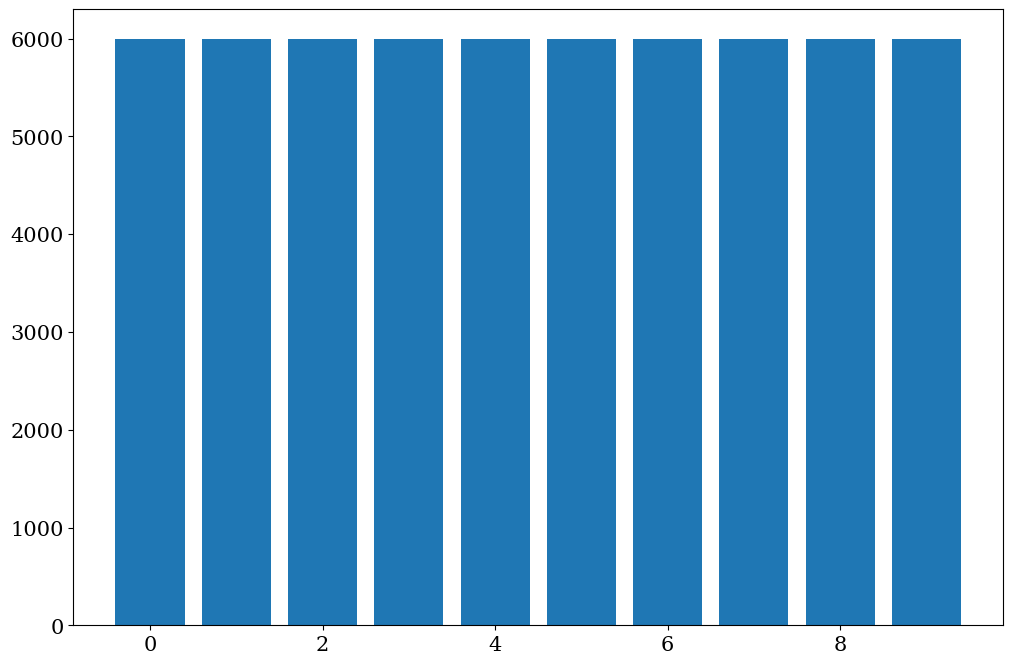

In [14]:
plt.figure(figsize=(12,8))
plt.bar(train_y[0].value_counts().index,train_y[0].value_counts().values)
plt.savefig("plots_lab_2/class_distribution.png")
plt.show()

In [15]:
train_y_one_hot=tf.keras.utils.to_categorical(train_y,num_classes=10)
test_y_one_hot=tf.keras.utils.to_categorical(test_y,num_classes=10)

print(f"Original train_y shape: {train_y.shape}")
print(f"One-hot encoded train_y shape: {train_y_one_hot.shape}")
print(f"Original test_y shape: {test_y.shape}")
print(f"One-hot encoded test_y shape: {test_y_one_hot.shape}")

Original train_y shape: (60000, 1)
One-hot encoded train_y shape: (60000, 10)
Original test_y shape: (10000, 1)
One-hot encoded test_y shape: (10000, 10)


In [16]:
mm=MinMaxScaler()
train_x=mm.fit_transform(train_x)
test_x=mm.transform(test_x)

In [17]:
train_x = pd.DataFrame(train_x)
train_x.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.004348,0.0,0.0,0.000000,0.000000,...,0.466667,0.447059,0.509804,0.298039,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.086275,...,0.000000,0.000000,0.003922,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.129921,0.376471,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
train_x.shape

(60000, 784)

In [19]:
test_x.shape

(10000, 784)

In [20]:
train_y.shape

(60000, 1)

In [21]:
test_y.shape

(10000, 1)

In [22]:
model=Sequential([
    Input(shape=(784,)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

I0000 00:00:1784820180.912698      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
history=model.fit(
    train_x,
    train_y_one_hot,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
  73/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5176 - loss: 1.4339

I0000 00:00:1784820184.422226     146 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8193 - loss: 0.5088 - val_accuracy: 0.8497 - val_loss: 0.4028
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8626 - loss: 0.3780 - val_accuracy: 0.8571 - val_loss: 0.3856
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8756 - loss: 0.3398 - val_accuracy: 0.8692 - val_loss: 0.3744
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8835 - loss: 0.3148 - val_accuracy: 0.8773 - val_loss: 0.3437
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8894 - loss: 0.2983 - val_accuracy: 0.8748 - val_loss: 0.3414
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8944 - loss: 0.2849 - val_accuracy: 0.8849 - val_loss: 0.3260
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9004 - loss: 0.2691 - val_accuracy: 0.8852 - val_loss: 0.3177
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9023 - loss: 0.2629 - val_accurac

In [26]:
pred_y=model.predict(test_x)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
pred_y=np.argmax(pred_y, axis=1)
test_y=test_y.values.ravel()

In [28]:
print("Accuracy:", accuracy_score(test_y, pred_y))
print("Precision:", precision_score(test_y, pred_y, average="weighted"))
print("Recall:", recall_score(test_y, pred_y, average="weighted"))
print("F1 Score:", f1_score(test_y, pred_y, average="weighted"))

Accuracy: 0.8739
Precision: 0.8778361908652415
Recall: 0.8739
F1 Score: 0.8740076562896576


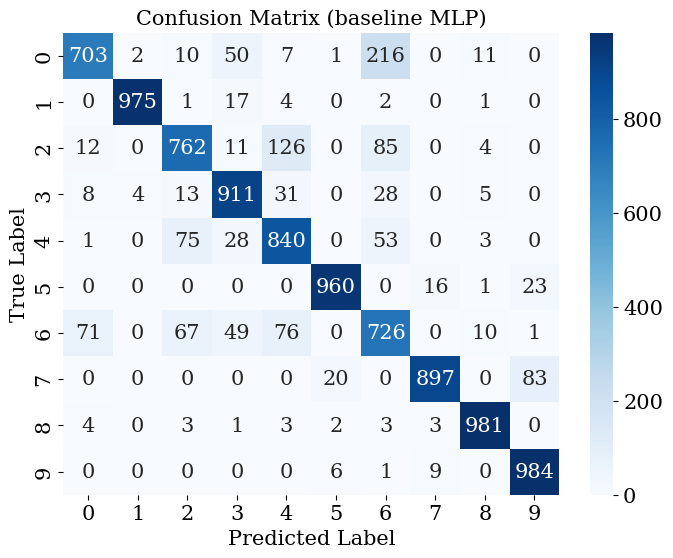

In [29]:
cm=confusion_matrix(test_y, pred_y)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10),yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (baseline MLP)")

plt.savefig(
    "plots_lab_2/confusion_matrix_baseline.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [30]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      1000
           1       0.99      0.97      0.98      1000
           2       0.82      0.76      0.79      1000
           3       0.85      0.91      0.88      1000
           4       0.77      0.84      0.80      1000
           5       0.97      0.96      0.97      1000
           6       0.65      0.73      0.69      1000
           7       0.97      0.90      0.93      1000
           8       0.97      0.98      0.97      1000
           9       0.90      0.98      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [31]:
def create_model(hidden_layers=2,hidden_neurons=128,learning_rate=0.001,optimizer="adam",activation="relu",dropout_rate=0.0):

    model=Sequential()
    model.add(Input(shape=(784,)))

    activation=activation.lower()

    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    optimizer = optimizer.lower()

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt,loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    return model

In [32]:
clf=KerasClassifier(model=create_model,verbose=0)

In [33]:
param_dist={
    "model__hidden_layers":[1,2,3],
    "model__hidden_neurons":[32, 64, 128, 256],
    "model__learning_rate":[0.1, 0.01, 0.001],
    "model__optimizer":["adam","sgd","rmsprop"],
    "model__activation":["relu","tanh","sigmoid"],
    "batch_size":[16, 32, 64, 128],
    "model__dropout_rate":[0.0,0.2,0.5],
    "epochs":[10, 20, 30]
}

In [34]:
import scikeras
print(scikeras.__file__)

/usr/local/lib/python3.12/dist-packages/scikeras/__init__.py


In [35]:
import sklearn
print(sklearn.__file__)

/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py


In [36]:
print(KerasClassifier.mro())

[<class 'scikeras.wrappers.KerasClassifier'>, <class 'scikeras.wrappers.BaseWrapper'>, <class 'sklearn.base.BaseEstimator'>, <class 'sklearn.utils._estimator_html_repr._HTMLDocumentationLinkMixin'>, <class 'sklearn.utils._metadata_requests._MetadataRequester'>, <class 'sklearn.base.ClassifierMixin'>, <class 'object'>]


In [37]:
random_search=RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="accuracy",
    random_state=42
)

train_y=train_y.values.ravel()
random_search.fit(train_x, train_y)

RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x7f3ebd1b8180>, verbose=0),
                   n_iter=15,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy')

In [38]:
import sklearn
import scikeras
import tensorflow as tf

print("sklearn:", sklearn.__version__)
print("SciKeras:", scikeras.__version__)
print("TensorFlow:", tf.__version__)

sklearn: 1.5.2
SciKeras: 0.13.0
TensorFlow: 2.20.0


In [39]:
print("Best Parameters:")
print(random_search.best_params_)

print()

print("Best Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}

Best Cross Validation Accuracy:
0.8906333333333334


In [40]:
best_model=random_search.best_estimator_
pred=best_model.predict(test_x)

print("Optimized Accuracy:",accuracy_score(test_y,pred))
print("Precision:",precision_score(test_y,pred,average="weighted"))
print("Recall:",recall_score(test_y,pred,average="weighted"))
print("F1 Score:",f1_score(test_y,pred,average="weighted"))

Optimized Accuracy: 0.8787
Precision: 0.8824493334212835
Recall: 0.8787
F1 Score: 0.8793204788993387


In [41]:
best_params=random_search.best_params_
optimized_model=Sequential()
optimized_model.add(Input(shape=(784,)))
for i in range(best_params["model__hidden_layers"]):
    optimized_model.add(
        Dense(
            best_params["model__hidden_neurons"],
            activation=best_params["model__activation"]
        )
    )
    if best_params["model__dropout_rate"]>0:
        optimized_model.add(
            Dropout(best_params["model__dropout_rate"])
        )

optimized_model.add(Dense(10, activation="softmax"))
if best_params["model__optimizer"]=="adam":
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_params["model__learning_rate"]
    )
elif best_params["model__optimizer"]=="sgd":
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=best_params["model__learning_rate"]
    )
else:
    optimizer=tf.keras.optimizers.RMSprop(
        learning_rate=best_params["model__learning_rate"]
    )

optimized_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_opt=optimized_model.fit(
    train_x,
    train_y,
    batch_size=best_params["batch_size"],
    epochs=best_params["epochs"],
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7889 - loss: 0.5884 - val_accuracy: 0.8249 - val_loss: 0.4842
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8386 - loss: 0.4560 - val_accuracy: 0.8378 - val_loss: 0.4359
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8492 - loss: 0.4187 - val_accuracy: 0.8653 - val_loss: 0.3805
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8562 - loss: 0.3967 - val_accuracy: 0.8644 - val_loss: 0.3747
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8632 - loss: 0.3789 - val_accuracy: 0.8646 - val_loss: 0.3763
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8686 - loss: 0.3676 - val_accuracy: 0.8695 - val_loss: 0.3729
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8722 - loss: 0.3592 - val_accuracy: 0.8755 - val_loss: 0.3593
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8730 - loss: 0.3521 - 

In [42]:
pred_opt=optimized_model.predict(test_x)
pred_opt=np.argmax(pred_opt, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [43]:
print("Optimized Accuracy:", accuracy_score(test_y, pred_opt))
print("Optimized Precision:", precision_score(test_y, pred_opt, average="weighted"))
print("Optimized Recall:", recall_score(test_y, pred_opt, average="weighted"))
print("Optimized F1 Score:", f1_score(test_y, pred_opt, average="weighted"))

Optimized Accuracy: 0.8808
Optimized Precision: 0.8817955929511341
Optimized Recall: 0.8808
Optimized F1 Score: 0.8809438757299746


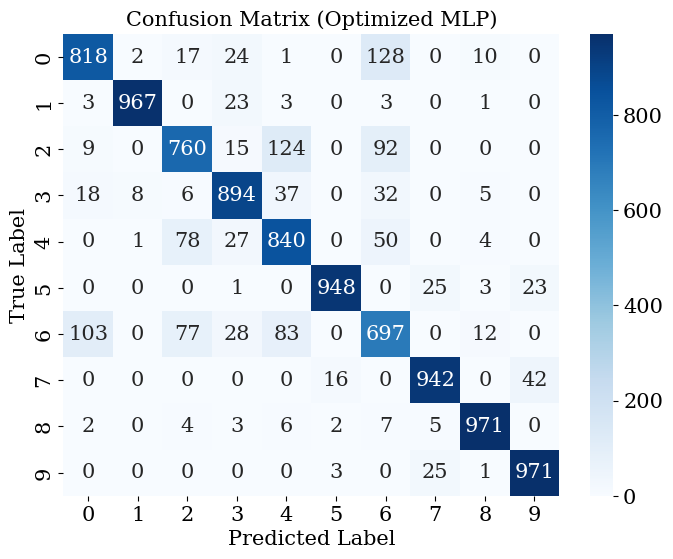

In [44]:
cm=confusion_matrix(test_y, pred_opt)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=range(10),yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Optimized MLP)")

plt.savefig(
    "plots_lab_2/confusion_matrix_optimized.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [45]:
print("\nClassification Report")
print(classification_report(test_y, pred_opt))


Classification Report
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.76      0.78      1000
           3       0.88      0.89      0.89      1000
           4       0.77      0.84      0.80      1000
           5       0.98      0.95      0.96      1000
           6       0.69      0.70      0.69      1000
           7       0.94      0.94      0.94      1000
           8       0.96      0.97      0.97      1000
           9       0.94      0.97      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [46]:
comparison=pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [
        accuracy_score(test_y, pred_y),
        precision_score(test_y, pred_y, average="weighted"),
        recall_score(test_y, pred_y, average="weighted"),
        f1_score(test_y, pred_y, average="weighted")
    ],
    "Optimized": [
        accuracy_score(test_y, pred),
        precision_score(test_y, pred, average="weighted"),
        recall_score(test_y, pred, average="weighted"),
        f1_score(test_y, pred, average="weighted")
    ]
})

print(comparison)

      Metric  Baseline  Optimized
0   Accuracy  0.873900   0.878700
1  Precision  0.877836   0.882449
2     Recall  0.873900   0.878700
3   F1 Score  0.874008   0.879320


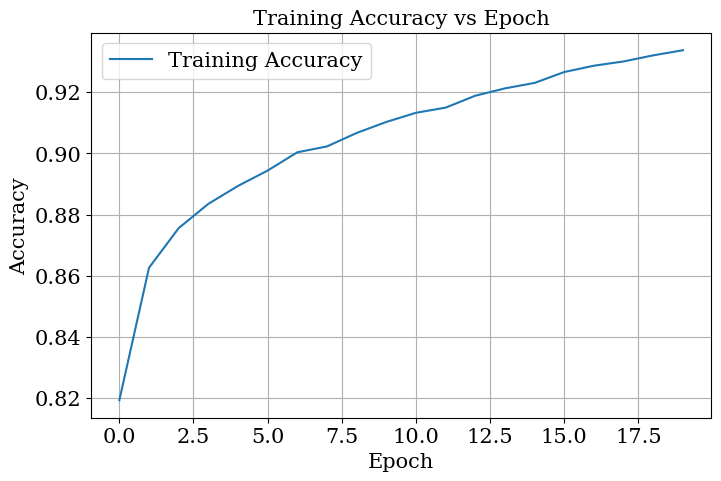

In [47]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.grid(True)
plt.legend()

plt.savefig(
    "plots_lab_2/training_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

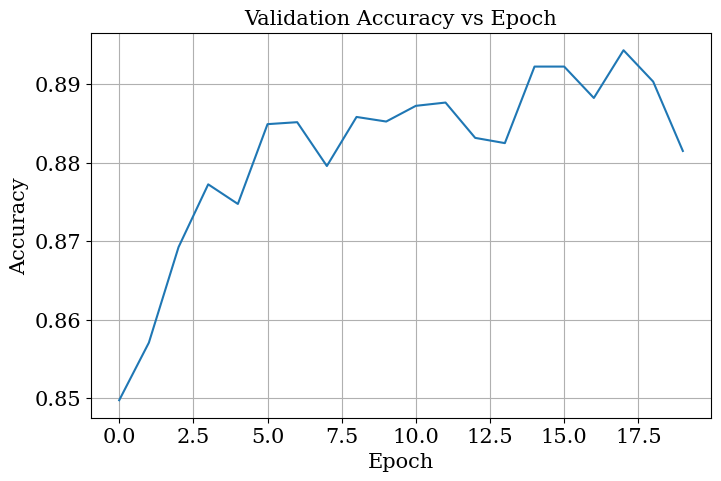

In [48]:
plt.figure(figsize=(8,5))
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.grid(True)

plt.savefig(
    "plots_lab_2/validation_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

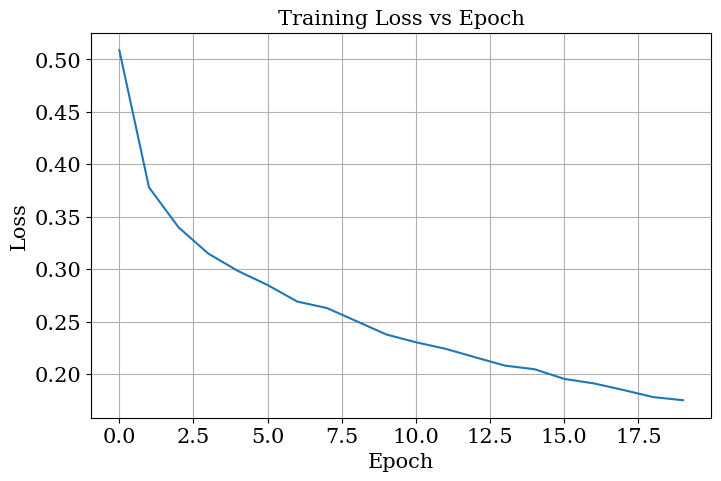

In [49]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)

plt.savefig(
    "plots_lab_2/training_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

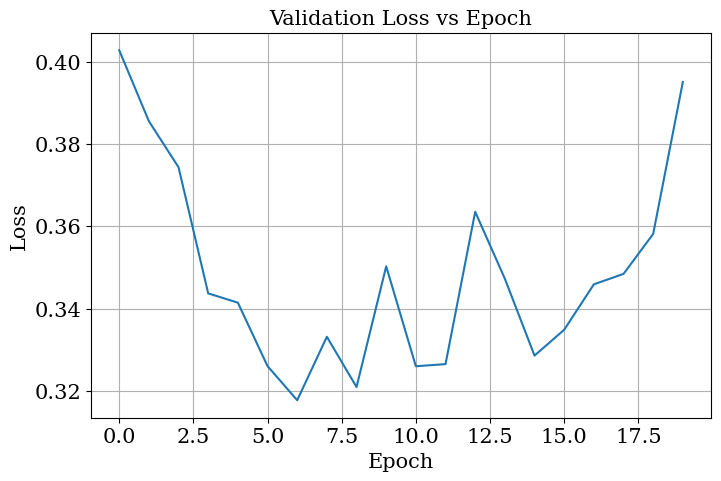

In [50]:
plt.figure(figsize=(8,5))
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")
plt.grid(True)

plt.savefig(
    "plots_lab_2/validation_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

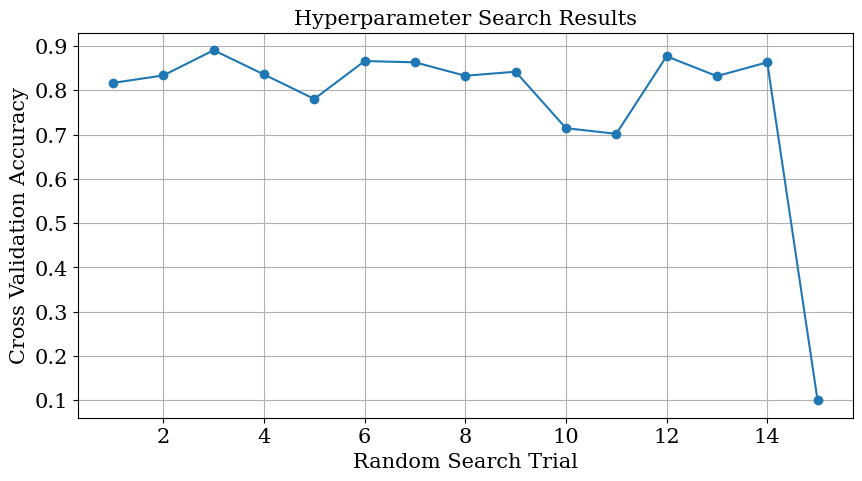

In [51]:
results=pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(10,5))
plt.plot(range(1,len(results)+1),results["mean_test_score"],marker="o")

plt.xlabel("Random Search Trial")
plt.ylabel("Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")
plt.grid(True)

plt.savefig(
    "plots_lab_2/hyperparameter_search_results.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

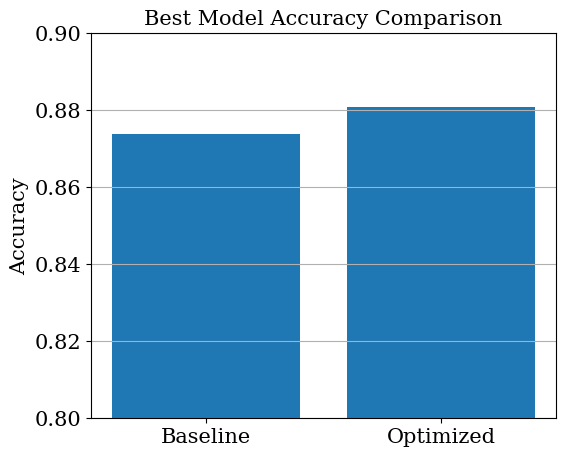

In [52]:
plt.figure(figsize=(6,5))

plt.bar(["Baseline", "Optimized"],[accuracy_score(test_y, pred_y),accuracy_score(test_y, pred_opt)])

plt.ylabel("Accuracy")
plt.title("Best Model Accuracy Comparison")

plt.ylim(0.80,0.90)

plt.grid(axis="y")

plt.savefig(
    "plots_lab_2/best_model_accuracy_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()